<a href="https://colab.research.google.com/github/Pradeep1694/Capstone-Project/blob/main/Capstone_Project_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [192]:
import pandas as pd

#-----------------Load dataset----------------
df = pd.read_csv("/content/amazon.csv")

print(df.dtypes)

print(df.shape)



product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object
(1465, 16)


In [193]:
#-----------------Null value analysis:-----------------
null_count = df.isnull().sum()

null_percent = (df.isnull().sum() / df.shape[0] * 100)

null_table = pd.DataFrame({
    "Missing Values": null_count,
    "Missing_percentage": null_percent
})

print(null_table)


print("\nColumns with >20% missing values:")
print(null_table[null_table["Missing_percentage"] > 20])

for col in df.select_dtypes(include='number').columns:
    if null_percent[col] < 20:
        df[col] = df[col].fillna(df[col].median())



                     Missing Values  Missing_percentage
product_id                        0            0.000000
product_name                      0            0.000000
category                          0            0.000000
discounted_price                  0            0.000000
actual_price                      0            0.000000
discount_percentage               0            0.000000
rating                            0            0.000000
rating_count                      2            0.136519
about_product                     0            0.000000
user_id                           0            0.000000
user_name                         0            0.000000
review_id                         0            0.000000
review_title                      0            0.000000
review_content                    0            0.000000
img_link                          0            0.000000
product_link                      0            0.000000

Columns with >20% missing values:
Empty DataFra

In [194]:
#--------------------Duplicate detection and removal:---------------------
duplicate_count = df.duplicated().sum()
print("number of duplicate rows:",duplicate_count)

rows_before = df.shape[0]
df = df.drop_duplicates()

rows_after = df.shape[0]
rows_removed = rows_before - rows_after
print("Rows removed:",rows_removed)

null_percent_after = (df.isnull().sum() / len(df) * 100)
print("\nPercentage after removing duplicates:")
print(null_percent_after)

number of duplicate rows: 0
Rows removed: 0

Percentage after removing duplicates:
product_id             0.000000
product_name           0.000000
category               0.000000
discounted_price       0.000000
actual_price           0.000000
discount_percentage    0.000000
rating                 0.000000
rating_count           0.136519
about_product          0.000000
user_id                0.000000
user_name              0.000000
review_id              0.000000
review_title           0.000000
review_content         0.000000
img_link               0.000000
product_link           0.000000
dtype: float64


In [195]:
# Data correction
print("Current Data Types:")
print(df.dtypes)

memory_before = df.memory_usage(deep=True).sum()
print("Memory before correction:", memory_before, "bytes")

# These columns need string cleaning and conversion to float.
df['discounted_price'] = df['discounted_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=False).astype(float)

df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = df['rating_count'].str.replace(',', '', regex=False)
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

category_cols = ["category", "user_name"]
for col in category_cols:
    df[col] = df[col].astype("category")

print("\nUpdated Data Types:")
print(df.dtypes)


memory_after = df.memory_usage(deep=True).sum()
print("Memory after correction:", memory_after, "bytes")

print("Memory Saved:", memory_before - memory_after, "bytes")

Current Data Types:
product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object
Memory before correction: 10865733 bytes

Updated Data Types:
product_id               object
product_name             object
category               category
discounted_price        float64
actual_price            float64
discount_percentage     float64
rating                  float64
rating_count            float64
about_product            object
user_id                  object
user_name              category
review_id                object
review_title             object
review_c

In [196]:
#Descriptive statistics and skewness

numeric_df = df.select_dtypes(include='number')
print("Descriptive Statistics:")
print(numeric_df.describe())


skewness = numeric_df.skew()

print("\nskeness of Numeric colimns")
print(skewness)

#Find the column with the highest absolute skewness
highest_skew_col = skewness.abs().idxmax()
highestt_skew_value = [highest_skew_col]

print("\nColumn with highest absolute skewness:")
print("Column:", highest_skew_col)
print("skewness Value:", highestt_skew_value)

print("\nColumn with highest absolute skewness:", highest_skew_col)



Descriptive Statistics:
       discounted_price   actual_price  discount_percentage       rating  \
count       1465.000000    1465.000000          1465.000000  1464.000000   
mean        3125.310874    5444.990635            47.691468     4.096585   
std         6944.304394   10874.826864            21.635905     0.291674   
min           39.000000      39.000000             0.000000     2.000000   
25%          325.000000     800.000000            32.000000     4.000000   
50%          799.000000    1650.000000            50.000000     4.100000   
75%         1999.000000    4295.000000            63.000000     4.300000   
max        77990.000000  139900.000000            94.000000     5.000000   

        rating_count  
count    1463.000000  
mean    18295.541353  
std     42753.864952  
min         2.000000  
25%      1186.000000  
50%      5179.000000  
75%     17336.500000  
max    426973.000000  

skeness of Numeric colimns
discounted_price       4.452395
actual_price           4

In [197]:
col1 ="discounted_price"
col2 ="actual_price"

Q1 = df[col1].quantile(0.25)
Q3 = df[col1].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col1] < lower_bound) | (df[col1] > upper_bound)]
print(f"\n Number of Outliers in '{col1}':", len(outliers))


col1 ="discounted_price"
col2 ="actual_price"

Q1 = df[col2].quantile(0.25)
Q3 = df[col2].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col1] < lower_bound) | (df[col2] > upper_bound)]
print(f"\n Number of Outliers in '{col2}':", len(outliers))


 Number of Outliers in 'discounted_price': 217

 Number of Outliers in 'actual_price': 213


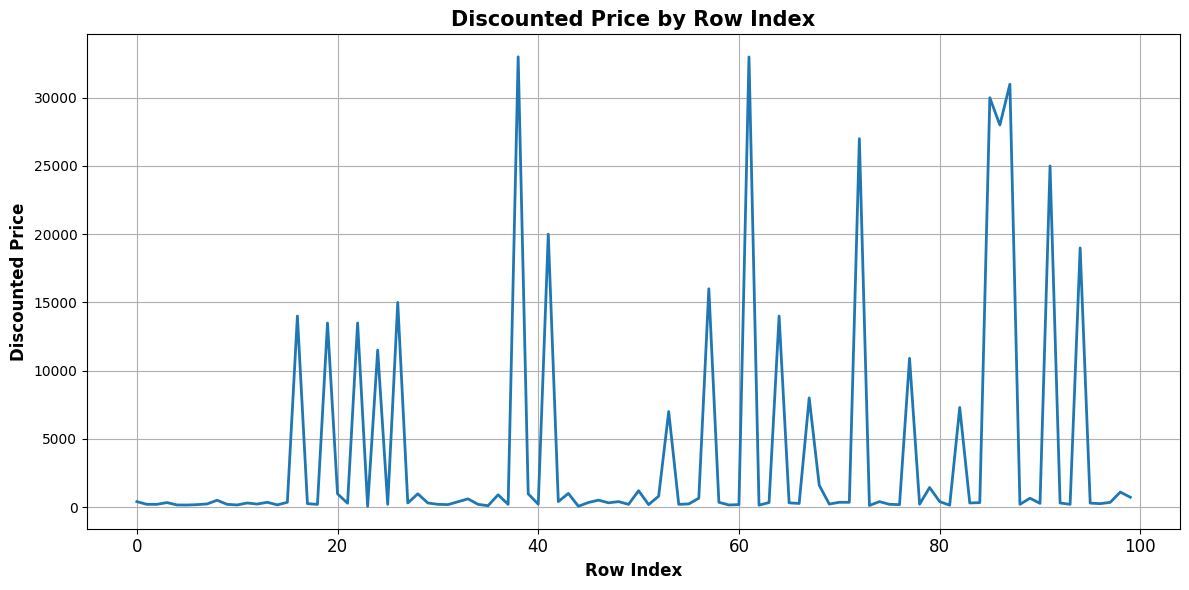

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_sorted = df.sort_index()

plt.figure(figsize=(12, 6))
plt.plot(df.index[:100], df_sorted["discounted_price"][:100], linewidth=2)

plt.title("Discounted Price by Row Index", fontsize=15, fontweight="bold")
plt.xlabel("Row Index", fontsize=12, fontweight="bold")
plt.ylabel("Discounted Price", fontsize=12, fontweight="bold")
plt.xticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("discounted_price_by_row_index.png")
plt.show()


/tmp/ipykernel_3774/1885161830.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_price = df.groupby("category")["discounted_price"].mean()
/tmp/ipykernel_3774/1885161830.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


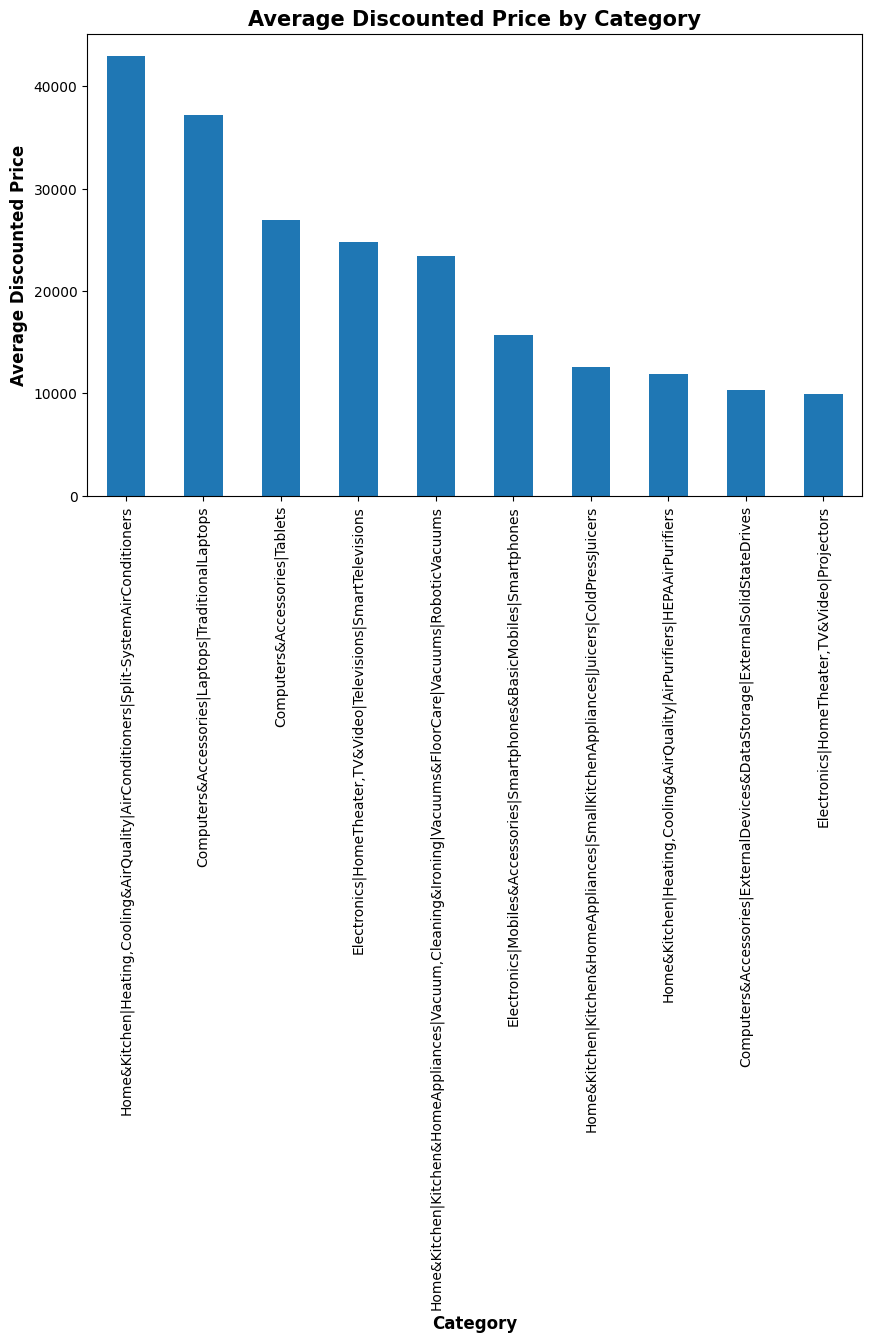

In [199]:

average_price = df.groupby("category")["discounted_price"].mean()
top10 = average_price.sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top10.plot(kind='bar')
plt.title('Average Discounted Price by Category', fontsize=15, fontweight="bold")
plt.xlabel("Category", fontsize=12, fontweight="bold")
plt.ylabel("Average Discounted Price", fontsize=12, fontweight="bold")
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("average_discounted_price_by_category.png")
plt.show()

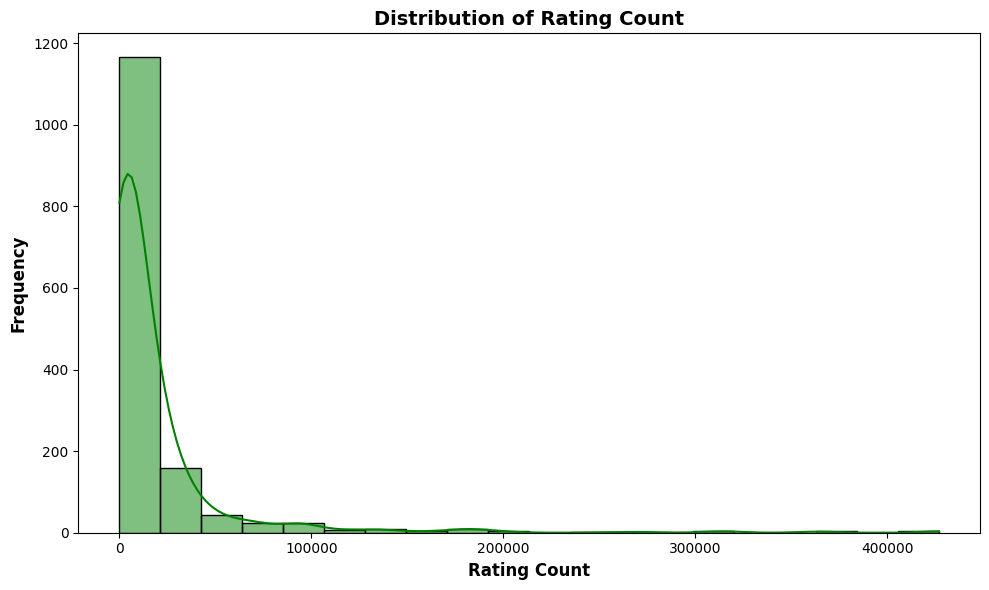

In [200]:
plt.figure(figsize=(10, 6))
sns.histplot(df["rating_count"], bins=20, color='green', kde=True)

plt.title("Distribution of Rating Count", fontsize=14, fontweight = "bold")
plt.xlabel("Rating Count", fontsize=12, fontweight = "bold")
plt.ylabel("Frequency", fontsize=12, fontweight = "bold")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("distribution_of_rating_count.png")
plt.show()

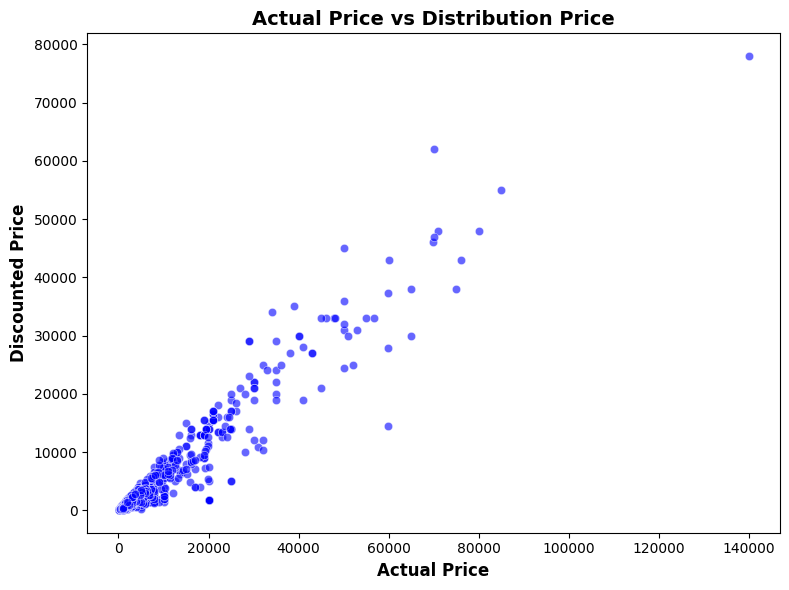

In [201]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="actual_price", y="discounted_price", data=df, alpha=0.6, color="blue")

plt.title("Actual Price vs Distribution Price", fontsize=14, fontweight="bold")
plt.xlabel("Actual Price", fontsize=12, fontweight="bold")
plt.ylabel("Discounted Price", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("Actual Price vs Distribution Price.png")
plt.show()

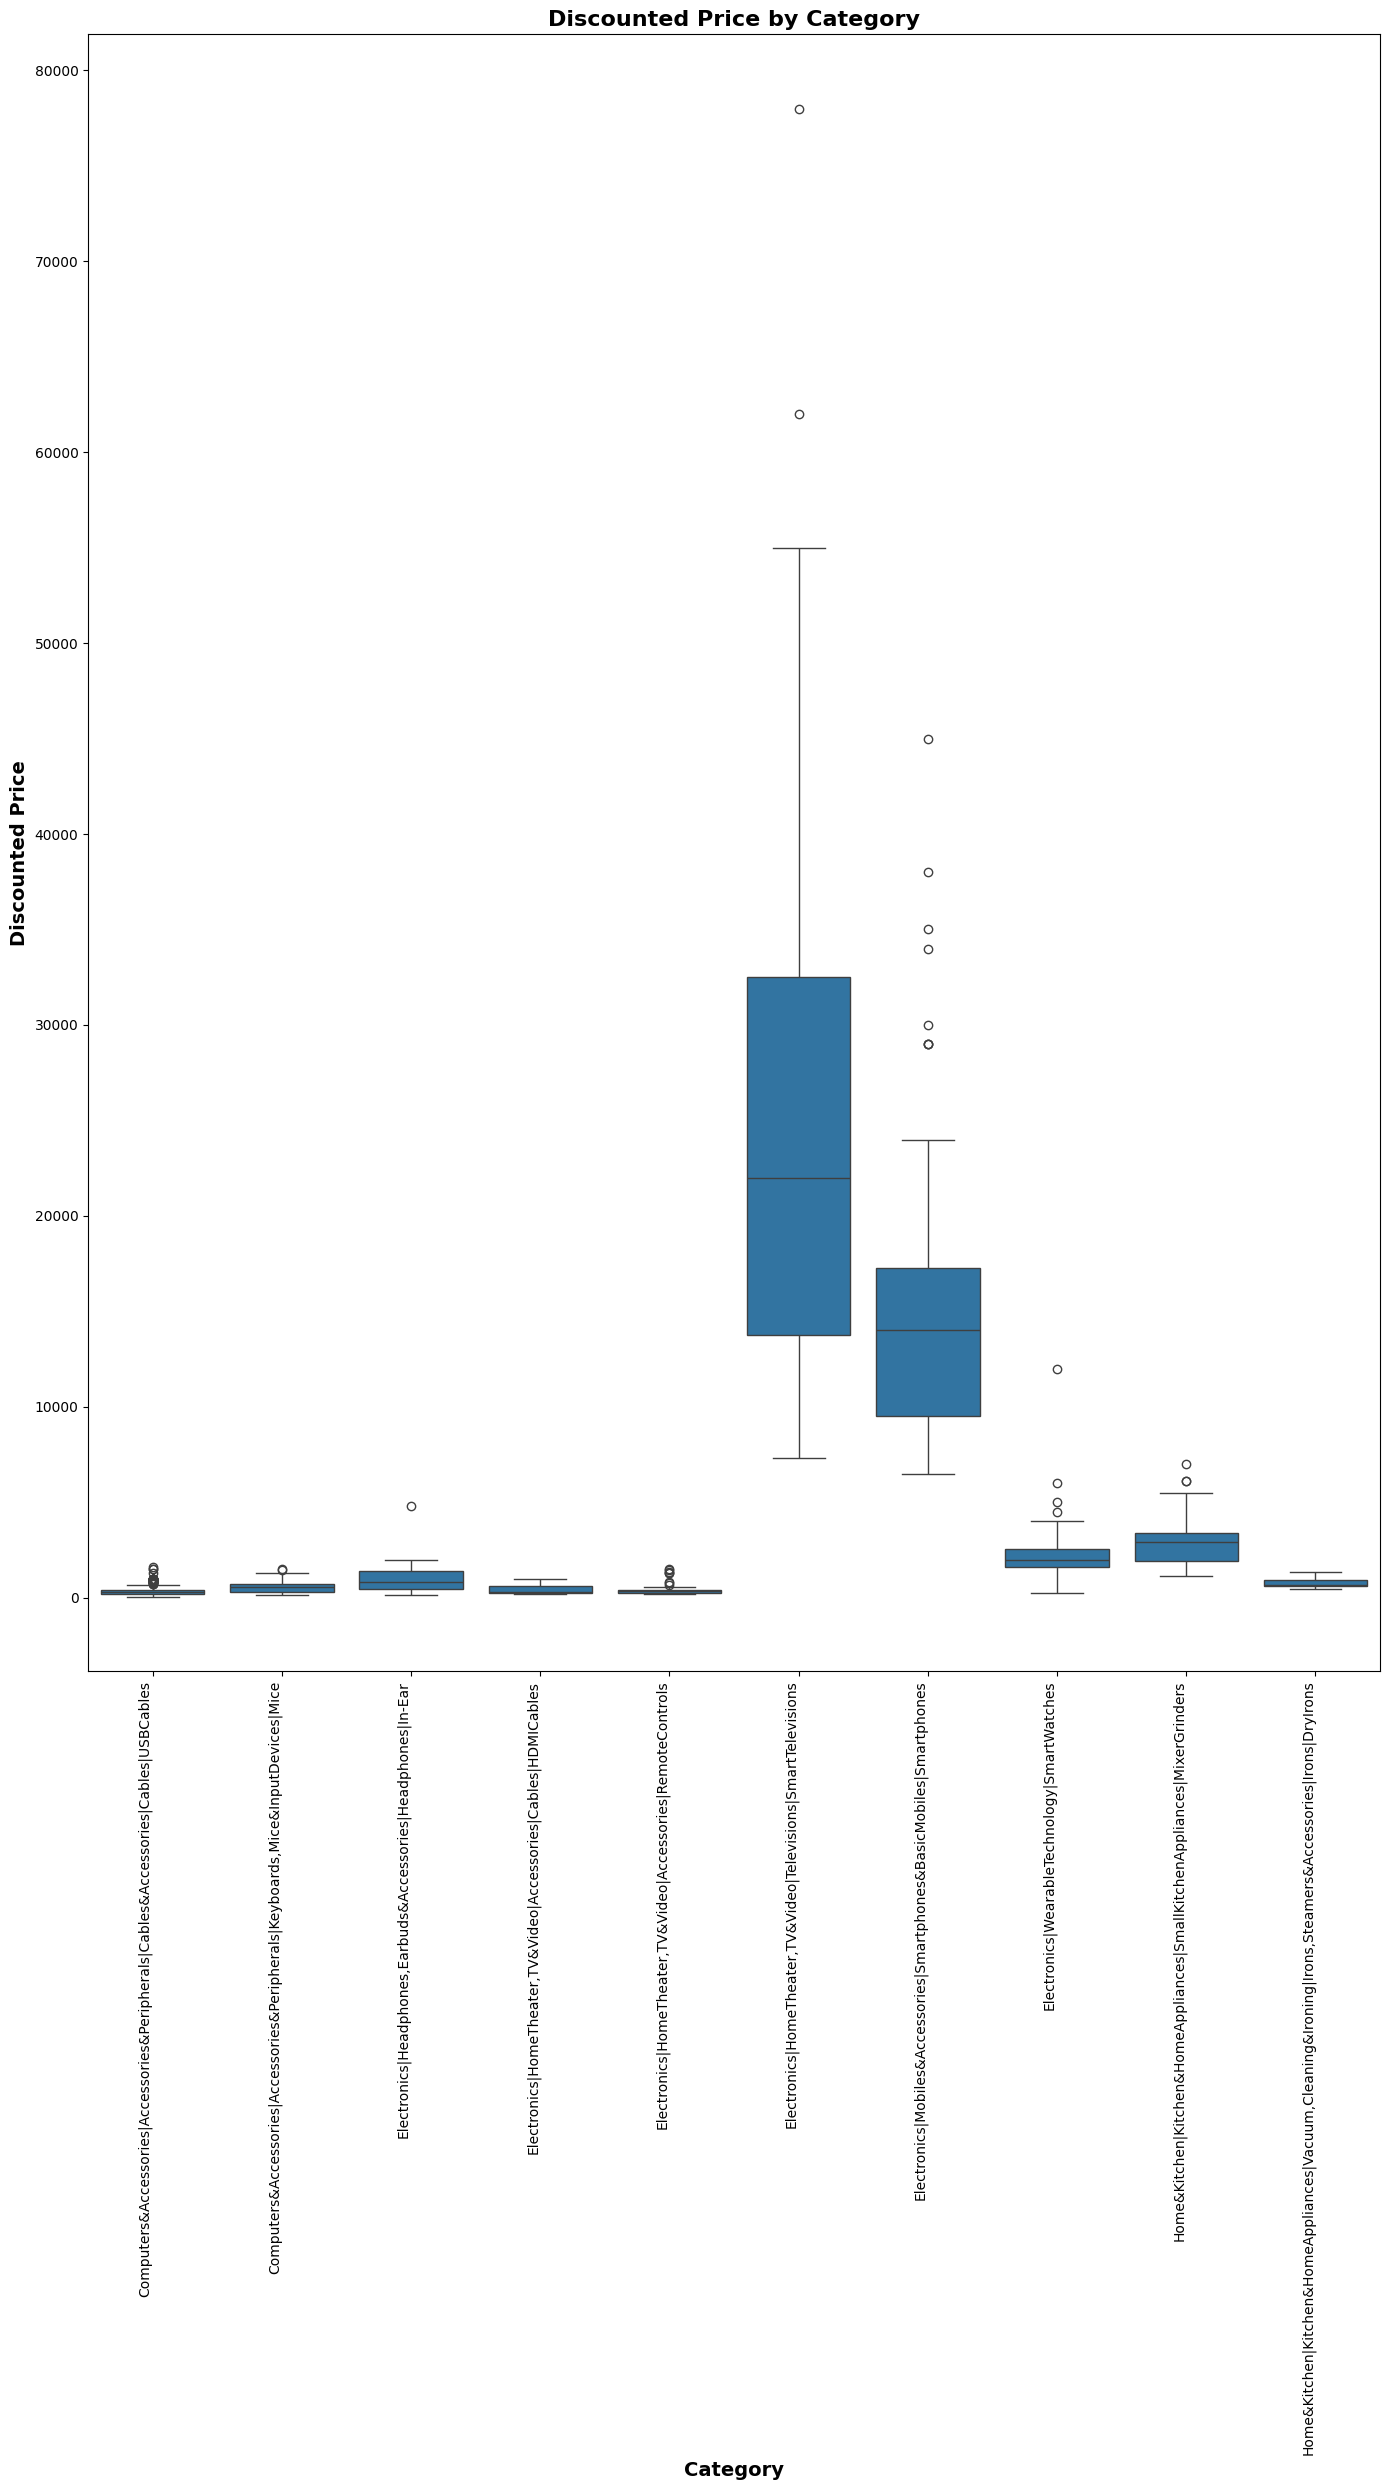

In [202]:
top_categories = df['category'].value_counts().head(10).index
df_box = df[df["category"].isin(top_categories)].copy() # Create a copy to avoid SettingWithCopyWarning
df_box['category'] = df_box['category'].cat.remove_unused_categories() # Remove unused categories

plt.figure(figsize=(14, 25)) # Increased figure height further
sns.boxplot(x="category", y="discounted_price", data=df_box)

plt.title("Discounted Price by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=14, fontweight="bold")
plt.ylabel("Discounted Price", fontsize=14, fontweight="bold")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.savefig("discounted Price by category.png")
plt.show()

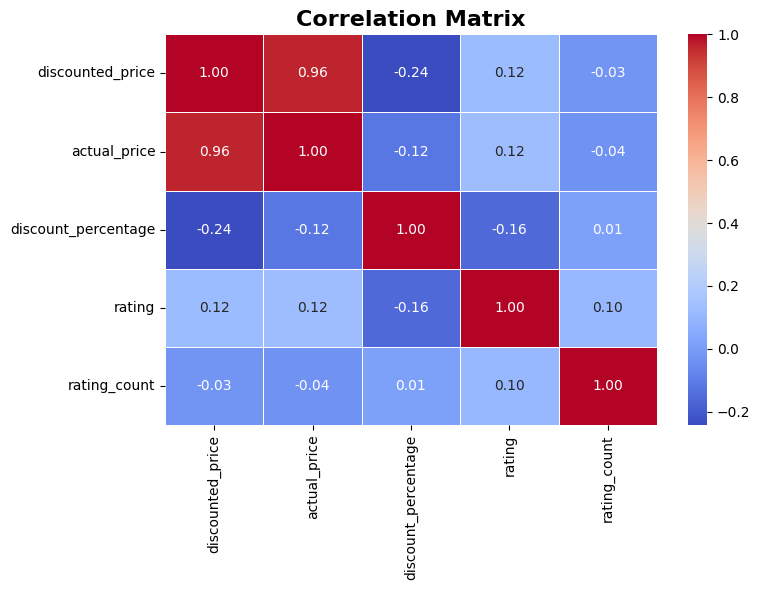

In [203]:
numeric_df =df.select_dtypes(include='number')

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

In [204]:
numeric_cols = df.select_dtypes(include='number')

skewness = numeric_cols.skew().abs().sort_values(ascending=False)

print(skewness)

top2_cols = skewness.head(2).index.tolist()
print("Top 2 skewed columns:", top2_cols)

for col in top2_cols:
  print(f"\ncolumn: {col}")
  print("Mean  :", df[col].mean())
  print("Median:", df[col].median())

for col in top2_cols:
  df[col] = df[col].fillna(df[col].median())

for col in top2_cols:
  print(f"{col}:",df[col].isnull().sum())

rating_count           5.673784
actual_price           4.559879
discounted_price       4.452395
rating                 1.242895
discount_percentage    0.290532
dtype: float64
Top 2 skewed columns: ['rating_count', 'actual_price']

column: rating_count
Mean  : 18295.541353383458
Median: 5179.0

column: actual_price
Mean  : 5444.990634812287
Median: 1650.0
rating_count: 0
actual_price: 0


In [205]:
pearson_corr = df.select_dtypes(include="number").corr(method="pearson")

spearman_corr = df.select_dtypes(include="number").corr(method="spearman")

print("Pearson Correlation Matrix")
print(pearson_corr)

print("\nSpearman Correlation Matrix")
print(spearman_corr)

difference = (spearman_corr - pearson_corr).abs()

print("Difference Matrix")
print(difference)

diff_pairs = difference.unstack()

diff_pairs = diff_pairs[diff_pairs.index.get_level_values(0)  !=
                        diff_pairs.index.get_level_values(1)]

diff_pairs = diff_pairs.sort_values(ascending=False)

diff_pairs = diff_pairs[~diff_pairs.index.duplicated()]
print("Top 3 column pairs with the largest difference:")
print(diff_pairs.head(3))

Pearson Correlation Matrix
                     discounted_price  actual_price  discount_percentage  \
discounted_price             1.000000      0.961915            -0.242412   
actual_price                 0.961915      1.000000            -0.118098   
discount_percentage         -0.242412     -0.118098             1.000000   
rating                       0.120337      0.121642            -0.155375   
rating_count                -0.027081     -0.035959             0.011097   

                       rating  rating_count  
discounted_price     0.120337     -0.027081  
actual_price         0.121642     -0.035959  
discount_percentage -0.155375      0.011097  
rating               1.000000      0.101535  
rating_count         0.101535      1.000000  

Spearman Correlation Matrix
                     discounted_price  actual_price  discount_percentage  \
discounted_price             1.000000      0.932787            -0.372991   
actual_price                 0.932787      1.000000        

In [206]:
categorical_col = 'category'
numeric_col = 'discounted_price'
grouped_data = df.groupby(categorical_col, observed=False)[numeric_col].agg(['mean', 'std', 'count'])
print(grouped_data)

print("\ngroup with highest mean:")
print(grouped_data['mean'].idxmax())
print(grouped_data['mean'].max())

print("\ngroup with highest standard deviation:")
print(grouped_data['std'].idxmin())
print(grouped_data['std'].min())

highest_mean = grouped_data["mean"].max()
lowest_mean = grouped_data["mean"].min()

ratio = highest_mean/lowest_mean
print("Ratio:", ratio)

                                                           mean         std  \
category                                                                      
Car&Motorbike|CarAccessories|InteriorAccessorie...  2339.000000         NaN   
Computers&Accessories|Accessories&Peripherals|A...   221.500000  102.530483   
Computers&Accessories|Accessories&Peripherals|A...   649.000000         NaN   
Computers&Accessories|Accessories&Peripherals|A...   574.000000  530.330086   
Computers&Accessories|Accessories&Peripherals|A...   749.000000  141.421356   
...                                                         ...         ...   
OfficeProducts|OfficePaperProducts|Paper|Statio...   150.000000  141.421356   
OfficeProducts|OfficePaperProducts|Paper|Statio...   255.000000  233.345238   
OfficeProducts|OfficePaperProducts|Paper|Statio...   329.000000  213.546248   
OfficeProducts|OfficePaperProducts|Paper|Statio...   244.333333  113.067826   
Toys&Games|Arts&Crafts|Drawing&PaintingSupplies...  

In [207]:
import os
print(os.listdir())
df.to_csv("cleaned_data.csv", index=False)

print("Cleaned dataset saved sucessfully!")

['.config', 'discounted Price by category.png', 'distribution_of_rating_count.png', 'cleaned_data.csv', 'average_discounted_price_by_category.png', 'amazon.csv', 'correlation_matrix.png', 'Actual Price vs Distribution Price.png', 'discounted_price_by_row_index.png', 'sample_data']
Cleaned dataset saved sucessfully!
